# Домашнее задание к занятию «Feature Select»

Выполнил: Ярослав Золотухин

## Генерация данных и рассчет средней точности логистической регрессии

In [27]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
x_data_generated, y_data_generated = make_classification(scale=1)
acc = cross_val_score(LogisticRegression(), x_data_generated, y_data_generated, scoring='accuracy').mean()
print(acc)

0.86


## Статистические методы для отбора признаков

Выбираем признаки на основе матрицы корреляции.

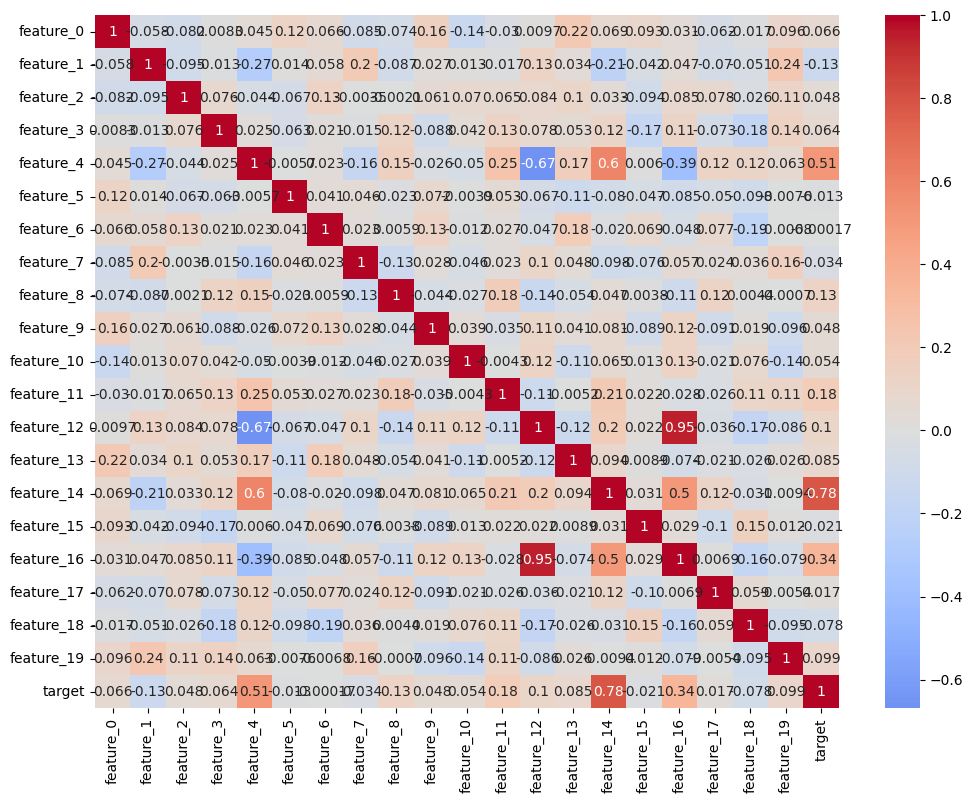

In [29]:
df_features = pd.DataFrame(x_data_generated, columns=[f'feature_{i}' for i in range(x_data_generated.shape[1])])
df_generated = df_features.copy()
df_generated['target'] = y_data_generated

corr = df_generated.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

Тепловая карта показывает, что между есть сильные связи между: 

- feature_15 и feature_4
- feature_15 и feature_8
- feature_8 и feature_1

Уберем из выборки признаки feature_8 и feature_15, из-за их меньшей связи с целевой переменной.

In [30]:
cols_to_drop = ["feature_8", "feature_15", "target"]
df_del_col = df_generated.drop(columns=cols_to_drop)
acc_del_col = cross_val_score(LogisticRegression(), df_del_col, df_generated['target'], scoring='accuracy').mean()
print(acc_del_col)

0.8400000000000001


Точность осталась прежней.

In [31]:
from sklearn.metrics import mutual_info_score

for col in df_generated[:-1]:
    print('target -', col, mutual_info_score(df_generated[col], df_generated['target']))

target - feature_0 0.6931471805599458
target - feature_1 0.6931471805599458
target - feature_2 0.6931471805599458
target - feature_3 0.6931471805599458
target - feature_4 0.6931471805599458
target - feature_5 0.6931471805599458
target - feature_6 0.6931471805599458
target - feature_7 0.6931471805599458
target - feature_8 0.6931471805599458
target - feature_9 0.6931471805599458
target - feature_10 0.6931471805599458
target - feature_11 0.6931471805599458
target - feature_12 0.6931471805599458
target - feature_13 0.6931471805599458
target - feature_14 0.6931471805599458
target - feature_15 0.6931471805599458
target - feature_16 0.6931471805599458
target - feature_17 0.6931471805599458
target - feature_18 0.6931471805599458
target - feature_19 0.6931471805599458
target - target 0.6931471805599458


/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for t

Признаки показали идентичный mutual_info_score. Связано это с тем, что данные сгенерированы, при генерации дополнительный шум не был задан.

### Удалим признаки, которые имеют низкую вариантивность. Значение порога возьмем 80%

In [32]:
df_features.var().sort_values()

feature_18    0.698885
feature_7     0.810462
feature_4     0.883891
feature_11    0.890503
feature_17    0.896819
feature_6     0.917776
feature_10    0.923343
feature_19    0.998435
feature_9     1.014665
feature_2     1.034402
feature_15    1.043936
feature_0     1.064624
feature_5     1.070235
feature_8     1.109469
feature_1     1.148503
feature_3     1.210959
feature_13    1.250810
feature_14    1.711615
feature_12    1.959672
feature_16    2.210430
dtype: float64

In [33]:
from sklearn.feature_selection import VarianceThreshold


sel = VarianceThreshold(threshold=0.8)
x_data_selected = sel.fit_transform(df_features)
x_data_selected.shape

(100, 19)

Было исключено два признака. Рассчитаем точность логистической модели после преобразований.

In [34]:
acc_2 = cross_val_score(LogisticRegression(), x_data_selected, y_data_generated, scoring='accuracy').mean()
print(acc_2)

0.89


Точность стала выше.

## Отбор признаков на основе дисперсионного анализа

In [35]:
from sklearn.feature_selection import SelectKBest
X_new = SelectKBest(k=5).fit_transform(x_data_generated, y_data_generated)
acc_3 = cross_val_score(LogisticRegression(), X_new, y_data_generated, scoring='accuracy').mean()
print(X_new.shape)
print(acc_3)

(100, 5)
0.9


Точность улучшена

## Отбор с использованием моделей

In [36]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_sc = scaler.fit_transform(x_data_generated)

logReg_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1,
    random_state=1,
    max_iter=1000
)

selector = SelectFromModel(logReg_l1, max_features=5, threshold=-np.inf)
X_tr = selector.fit_transform(X_sc, y_data_generated)

acc_4 = cross_val_score(
    LogisticRegression(random_state=1, max_iter=1000),
    X_tr,
    y_data_generated,
    scoring='accuracy'
).mean()

print(X_tr.shape)
print(acc_4)

(100, 5)
0.9099999999999999


Точность показала хороший результат.

In [37]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(random_state=1)
model_rf.fit(x_data_generated, y_data_generated) # обучение

importances = model_rf.feature_importances_

# выберем 5 самых важных признаков
top_features = np.argsort(importances)[-5:]

x_data_rf_selected = x_data_generated[:, top_features]

acc_5 = cross_val_score(LogisticRegression(), x_data_rf_selected, y_data_generated, scoring='accuracy').mean()
print(x_data_rf_selected.shape)
print(acc_5)


(100, 5)
0.9


Точность на показала хороший результат, но не лучше чем при отборе на основе моделей.

## Перебор признаков

In [38]:
from sklearn.feature_selection import SequentialFeatureSelector


sfs_backward = SequentialFeatureSelector(
    LogisticRegression(random_state=1), direction="backward"
)
sfs_backward.fit(x_data_generated, y_data_generated)
X_tr_seq = sfs_backward.transform(x_data_generated)
acc_6 = cross_val_score(LogisticRegression(), X_tr_seq, y_data_generated, scoring='accuracy').mean()
print(X_tr_seq.shape)
print(acc_6)

(100, 10)
0.9200000000000002


Сведем полученные результаты в таблицу.

In [39]:
results = pd.DataFrame({
    'Метод': [
        'Без отбора признаков',
        'Матрица корреляции',
        'VarianceThreshold',
        'SelectKBest',
        'SelectFromModel',
        'RandomForest feature_importances',
        'SequentialFeatureSelector'
    ],
    'Количество признаков': [
        x_data_generated.shape[1],
        df_del_col.shape[1],
        x_data_selected.shape[1],
        X_new.shape[1],
        X_tr.shape[1],
        x_data_rf_selected.shape[1],
        X_tr_seq.shape[1]
    ],
    'Accuracy': [
        acc,
        acc_del_col,
        acc_2,
        acc_3,
        acc_4,
        acc_5,
        acc_6
    ]
})

results['Accuracy'] = results['Accuracy'].round(4)
results

,Метод,Количество признаков,Accuracy
0,Без отбора признаков,20,0.86
1,Матрица корреляции,18,0.84
2,VarianceThreshold,19,0.89
3,SelectKBest,5,0.90
4,SelectFromModel,5,0.91
5,RandomForest feature_importances,5,0.90
6,SequentialFeatureSelector,10,0.92


# Вывод

В ходе данного домашнего задания были рассмотрены различные варианты методов отбора признаков. Перебор признаков для лучший результат, но на практических данных он может занять продолжительное время выполнения.

Также хороший результат продемонстрировали методы отбора на основе моделей.